# `OcpSolver`: a chain-mass optimal control problem

`OcpSolver` is cuPIQP's high-level interface for optimal control. Instead of assembling
block-structured QP matrices by hand, you describe the control problem stage by stage and
the solver factorizes the block structure directly.

This notebook drives a **chain of masses** back to rest -- a classic scalable benchmark of
$M$ point masses connected by springs and dampers, where $M-1$ of them are actuated. It is
a straightforward linear-quadratic regulator with box limits on the states and inputs:
every field maps to a single `set(...)` call, no state augmentation and no cross-stage
coupling. We then batch many problems in one call and run a receding-horizon (MPC) loop.

## The chain-mass system

$M$ masses on a line, each connected to its neighbours by a spring (constant $k$) and a
damper (constant $c$); mass $m$. The physical state stacks positions and velocities,
$x = [p;\, v] \in \mathbb{R}^{2M}$, and the $n_u = M-1$ actuated masses receive forces
$u$. The continuous dynamics $\dot{x} = A_c x + B_c u$ are discretized with a zero-order
hold at step $dt$ to give $x_{k+1} = A_d x_k + B_d u_k$.

We regulate the chain to the origin with a quadratic cost (state weight $Q$, input weight
$R$) and a terminal weight $Q_f$ taken from the discrete algebraic Riccati equation, so
the truncated horizon approximates the infinite-horizon LQR tail. The states are
box-limited to $\pm x_{\max}$ and the inputs to $\pm u_{\max}$.

In cuPIQP's `OcpSolver`, each stage carries a stage variable $y_k=[x_k;\,u_k]$, set with `set(field, k, value)`:

| field | meaning | stages |
|-------|---------|--------|
| `"Q"`, `"R"`, `"q"`, `"r"` | stage cost `[[Q, 0],[0, R]]` plus linear terms | `Q`,`q`: $0..N$; `R`,`r`: $0..N{-}1$ |
| `"A"`, `"B"`, `"E"`, `"b"` | dynamics $E_k x_{k+1}=A_k x_k+B_k u_k+b_k$ ($E=I$ default) | $0..N{-}1$ |
| `"x0"` | initial condition $x_0=x_{\text{init}}$ | $0$ |
| `"lbx"`/`"ubx"`, `"lbu"`/`"ubu"` | box bounds on the components chosen by `idxbx`/`idxbu` | state: $0..N$; input: $0..N{-}1$ |

Two points specific to this problem:

- **Box selection** is fixed at `setup` via `idxbx`/`idxbu`. We bound every physical state
  (`+/- x_max`) and every input (`+/- u_max`), so `idxbx = range(nx)` and
  `idxbu = range(nu)`.
- **Bounds are kept finite.** `OcpSolver` treats a bound as inactive by making it large, not
  by passing infinity; the `idxbx`/`idxbu` selection already decides which components carry a
  bound at all.

`OcpSolver` also supports a cross-term `S` and per-stage general inequalities
(`C`/`D`/`lg`/`ug`, enabled with `ng > 0`); this problem needs neither, so we leave `ng = 0`
and never set them.

In [1]:
import numpy as np
import cupy as cp
from scipy.signal import cont2discrete
from scipy.linalg import solve_discrete_are

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

from cupiqp import OcpSolver

assert cp.cuda.is_available(), "cuPIQP is GPU-only -- a CUDA device is required."


## Build the chain-mass model

The physical model is small to write out: tridiagonal spring coupling, identity velocity
coupling, then a zero-order-hold discretization.

In [2]:
# ---- chain-mass parameters ----
M  = 20                       # number of masses
N  = 40                      # horizon (dynamics steps); stages are 0 .. N
m, c, k_spring = 1.0, 0.1, 1.0
dt = 0.5

nx = 2 * M                   # physical state: M positions + M velocities
nu = M - 1                   # actuated masses
wq, wr = 1e3, 1e-1           # state / input cost weights

# Continuous-time model. SciPy's discretization and Riccati solve run on the
# host, so they take NumPy inputs; the *_h arrays are transient host scratch.
L = np.eye(M, k=-1)
A_c = np.block([
    [np.zeros((M, M)),                                              np.eye(M)],
    [(-2*k_spring*np.eye(M) + k_spring*L + k_spring*L.T) / m,       (-2*c*np.eye(M)) / m],
])
B_c = np.block([[np.zeros((2*M - nu, nu))], [np.eye(nu)]])
Ad_h, Bd_h, _, _, _ = cont2discrete((A_c, B_c, np.eye(nx), np.zeros((nx, nu))), dt, method="zoh")
Qf_h = solve_discrete_are(Ad_h, Bd_h, wq*np.eye(nx), wr*np.eye(nu))

# Arrays the solver consumes -- built as CuPy directly (one clean name each).
A  = cp.asarray(Ad_h)        # discretized dynamics  x_{k+1} = A x_k + B u_k
B  = cp.asarray(Bd_h)
Qf = cp.asarray(Qf_h)        # LQR terminal weight (discrete Riccati)
Q  = wq * cp.eye(nx)         # stage state cost
R  = wr * cp.eye(nu)         # stage input cost

# box limits, built directly on the GPU
x_max, u_max = 4.0, 0.5
lbx = cp.full(nx, -x_max); ubx = cp.full(nx, x_max)
lbu = cp.full(nu, -u_max); ubu = cp.full(nu, u_max)

print(f"masses M={M}, horizon N={N}, state nx={nx}, inputs nu={nu}")

masses M=20, horizon N=40, state nx=40, inputs nu=19


## Set up and solve

`setup` fixes the dimensions and which components are box-bounded. After that, `set` only
writes numerical values. 

In [3]:
idxbx = list(range(nx))      # bound every state
idxbu = list(range(nu))      # bound every input
x0 = cp.ones(nx)             # chain displaced from rest

ocp_solver = OcpSolver()
ocp_solver.settings.verbose = True
ocp_solver.setup(N=N, nx=nx, nu=nu, idxbx=idxbx, idxbu=idxbu)

# control stages 0 .. N-1: dynamics, stage cost, all bounds
for kk in range(N):
    ocp_solver.set("A", kk, A)
    ocp_solver.set("B", kk, B)
    ocp_solver.set("Q", kk, Q)
    ocp_solver.set("R", kk, R)
    ocp_solver.set("lbx", kk, lbx)
    ocp_solver.set("ubx", kk, ubx)
    ocp_solver.set("lbu", kk, lbu)
    ocp_solver.set("ubu", kk, ubu)

# terminal stage N: Riccati cost and state bounds (no input at stage N)
ocp_solver.set("Q", N, Qf)
ocp_solver.set("lbx", N, lbx)
ocp_solver.set("ubx", N, ubx)

ocp_solver.set("x0", 0, x0)
status = ocp_solver.solve()

----------------------------------------------------------
       cuPIQP v0.1.0 - GPU-accelerated PIQP solver        
                    (c) Fenglong Song                     
   Ecole Polytechnique Federale de Lausanne (EPFL) 2026   
----------------------------------------------------------
multistage backend:
batch size B = 1
variables n = 2419, num_diag_blocks(P) = 41, block_size(P) = (59, 59)
equality constraints p = 1680, num_diag_blocks(A) = 41, block_size(A) = (40, 59)
inequality constraints m = 0, num_diag_blocks(G) = 41, block_size(G) = (0, 59)
inequality lower bounds n_h_l = 0
inequality upper bounds n_h_u = 0
variable lower bounds n_x_l = 2419
variable upper bounds n_x_u = 2419

iter  prim_obj       dual_obj       duality_gap   prim_res      dual_res      rho         delta       mu          p_step   d_step
  0    5.32096e+04   -3.75175e+07   3.75707e+07   1.42143e+02   1.84007e+03   1.000e-06   1.000e-04   1.971e+04   0.0000   0.0000
  1    5.53836e+04   -7.15388e+06   7.2

The solution comes back as ready-made arrays: `x_traj` is `(B, N+1, nx)` and `u_traj`
is `(B, N, nu)`. We confirm the box limits hold to solver tolerance and that the chain is
driven from its displaced start back toward rest.

In [4]:
X = cp.asnumpy(ocp_solver.x_traj[0])        # (N+1, nx) states
U = cp.asnumpy(ocp_solver.u_traj[0])        # (N,   nu) inputs

print("solve status:", status)
print("x_traj:", X.shape, " u_traj:", U.shape)
print(f"max |state| = {np.abs(X).max():.4f}  (limit {x_max})")
print(f"max |u|     = {np.abs(U).max():.4f}  (limit {u_max})")
print(f"||x(0)|| = {np.linalg.norm(X[0]):.4f}  ->  ||x(N)|| = {np.linalg.norm(X[-1]):.4f}")


solve status: [<Status.CUPIQP_SOLVED: 0>]
x_traj: (41, 40)  u_traj: (40, 19)
max |state| = 1.7857  (limit 4.0)
max |u|     = 0.5000  (limit 0.5)
||x(0)|| = 6.3246  ->  ||x(N)|| = 0.0006


The input saturates at `u_max` -- a genuinely constrained solve -- while the states
stay within `x_max` and the chain settles toward the origin.

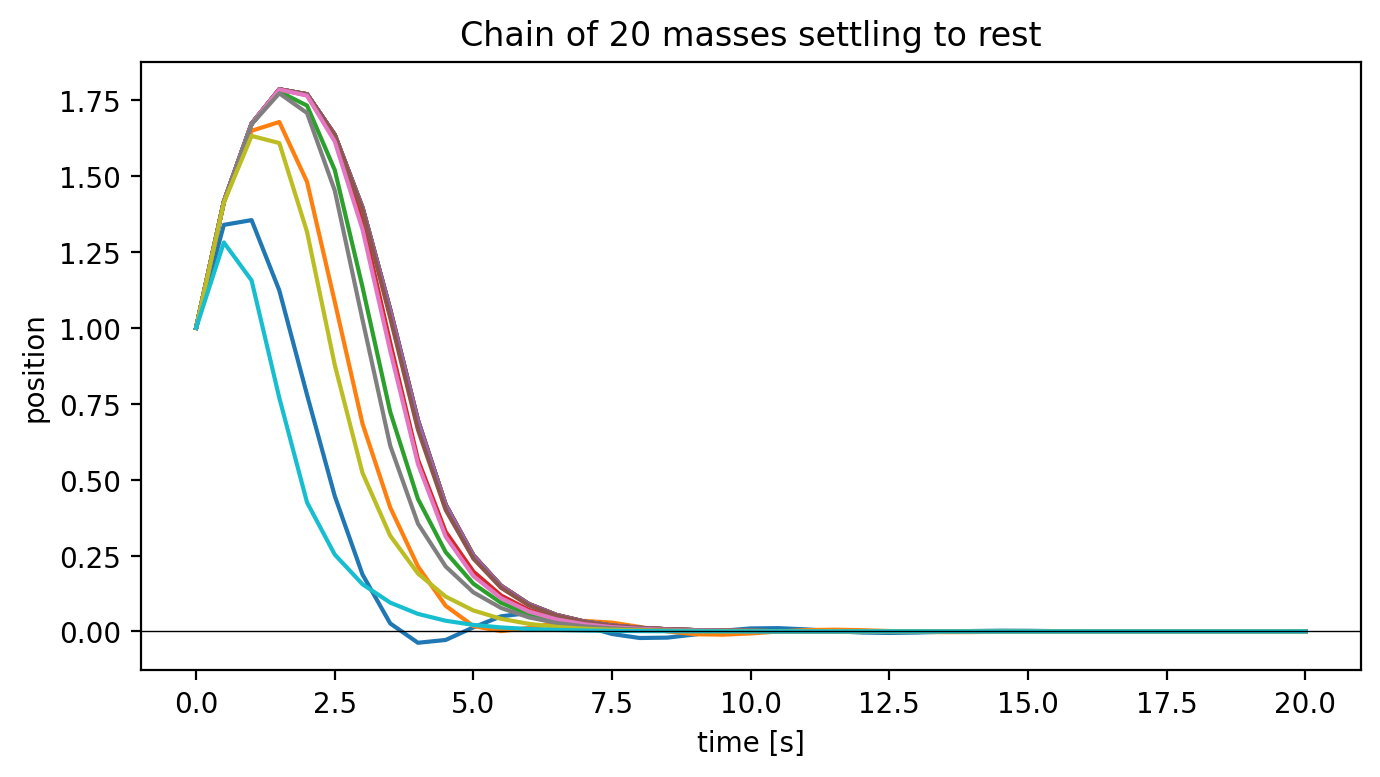

In [5]:
t = np.arange(N + 1) * dt
pos = X[:, :M]                          # first M components are positions
fig, ax = plt.subplots(figsize=(7, 4))
for j in range(M):
	ax.plot(t, pos[:, j], label=f"mass {j}")
ax.set_xlabel("time [s]"); ax.set_ylabel("position")
ax.set_title(f"Chain of {M} masses settling to rest")
ax.axhline(0.0, color="k", lw=0.5)
fig.tight_layout()
plt.show()


## Update solver in closed-loop

In closed loop control, the initial state changes each step, so we reuse the very same `ocp_solver` we set up above and call `set()` to update `x0`.

In [6]:
ocp_solver.settings.verbose = False     # quiet the 60 closed-loop re-solves

x_phys = cp.ones(nx)                        # physical plant state (on the GPU)
norms  = [float(cp.linalg.norm(x_phys))]
for t in range(60):
    ocp_solver.set("x0", 0, x_phys)         # only the initial state changes
    ocp_solver.solve()
    u0 = ocp_solver.get("u", 0)[0]          # first optimal input
    x_phys = A @ x_phys + B @ u0            # step the physical plant
    norms.append(float(cp.linalg.norm(x_phys)))

print(f"closed-loop ||x||: start {norms[0]:.3f}  ->  end {norms[-1]:.4f}")
print("driven to rest:", bool(norms[-1] < 0.05))

closed-loop ||x||: start 6.325  ->  end 0.0000
driven to rest: True


## Scaling vs PIQP (CPU): solve time against horizon

Both cuPIQP and PIQP exploit the block-tridiagonal KKT structure of an OCP, so the
per-solve cost grows linearly with the horizon $N$ -- the difference is *where* the work
runs. We solve the same chain-mass QP across a range of horizons with:

- **PIQP on the CPU**, using its multistage KKT solver
  (`settings.kkt_solver = piqp.KKTSolver.sparse_multistage`);
- **cuPIQP on the GPU** (the `OcpSolver` above, multistage backend).

PIQP takes a flat sparse QP, so we stack the stages as
$z = [x_0; u_0; \dots; x_{N-1}; u_{N-1}; x_N]$ and assemble `P`, `A`, and the box bounds
(cuPIQP builds the blocks internally). The CPU solver wins at short horizons -- it has
almost no fixed overhead -- while the GPU's near-flat scaling takes over once the
horizon is long enough to amortize its kernel-launch overhead.

Requires `piqp` (`pip install piqp`); the cell skips cleanly if it is not installed.

In [7]:
import time
try:
    import piqp
    import scipy.sparse as sp
    _have_piqp = True
except ImportError:
    _have_piqp = False
    print("piqp not installed -- skipping the CPU scaling comparison")

if _have_piqp:
    # host copies of the (canonical CuPy) data for the CPU solver / sparse assembly
    Ad_np, Bd_np = cp.asnumpy(A), cp.asnumpy(B)
    Q_np, R_np, Qf_np = cp.asnumpy(Q), cp.asnumpy(R), cp.asnumpy(Qf)
    x0_np = np.ones(nx)

    def build_sparse_ocp(N):
        """Stack the chain-mass OCP as a sparse QP z = [x_0,u_0,...,x_{N-1},u_{N-1},x_N]."""
        nz = nx + nu; dim = N*nz + nx
        P = sp.lil_matrix((dim, dim))
        for kk in range(N):
            P[kk*nz:kk*nz+nx, kk*nz:kk*nz+nx]         = Q_np
            P[kk*nz+nx:(kk+1)*nz, kk*nz+nx:(kk+1)*nz] = R_np
        P[N*nz:N*nz+nx, N*nz:N*nz+nx] = Qf_np
        p = (N+1)*nx; Aeq = sp.lil_matrix((p, dim)); beq = np.zeros(p)
        Aeq[:nx, :nx] = np.eye(nx); beq[:nx] = x0_np
        for kk in range(N):
            r = (kk+1)*nx
            Aeq[r:r+nx, kk*nz:kk*nz+nx]         = Ad_np
            Aeq[r:r+nx, kk*nz+nx:(kk+1)*nz]     = Bd_np
            Aeq[r:r+nx, (kk+1)*nz:(kk+1)*nz+nx] = -np.eye(nx)
        xl = np.empty(dim); xu = np.empty(dim)
        for kk in range(N):
            xl[kk*nz:kk*nz+nx] = -x_max; xu[kk*nz:kk*nz+nx] = x_max
            xl[kk*nz+nx:(kk+1)*nz] = -u_max; xu[kk*nz+nx:(kk+1)*nz] = u_max
        xl[N*nz:N*nz+nx] = -x_max; xu[N*nz:N*nz+nx] = x_max
        return P.tocsc(), np.zeros(dim), Aeq.tocsc(), beq, xl, xu

    def build_cupiqp(N):
        s = OcpSolver(); s.settings.verbose = False
        s.setup(N=N, nx=nx, nu=nu, idxbx=list(range(nx)), idxbu=list(range(nu)))
        for kk in range(N):
            s.set("A", kk, A); s.set("B", kk, B); s.set("Q", kk, Q); s.set("R", kk, R)
            s.set("lbx", kk, lbx); s.set("ubx", kk, ubx)
            s.set("lbu", kk, lbu); s.set("ubu", kk, ubu)
        s.set("Q", N, Qf); s.set("lbx", N, lbx); s.set("ubx", N, ubx)
        s.set("x0", 0, cp.asarray(x0_np))
        return s

    horizons = [20, 40, 80, 160, 320, 640, 1280]
    reps = 3
    t_cpu, t_gpu = [], []
    for N in horizons:
        # PIQP on the CPU with the multistage KKT solver
        P, cc, Aeq, beq, xl, xu = build_sparse_ocp(N)
        ps = piqp.SparseSolver(); ps.settings.verbose = False
        ps.settings.kkt_solver = piqp.KKTSolver.sparse_multistage
        ps.setup(P=P, c=cc, A=Aeq, b=beq, G=None, h_u=None, h_l=None, x_l=xl, x_u=xu)
        ps.solve()                                    # warm up
        t0 = time.perf_counter()
        for _ in range(reps): ps.solve()
        t_cpu.append((time.perf_counter() - t0) / reps * 1e3)

        # cuPIQP on the GPU (multistage backend)
        s = build_cupiqp(N)
        s.solve()                                     # warm up (compile / capture)
        ev0 = cp.cuda.Event(); ev1 = cp.cuda.Event(); ev0.record()
        for _ in range(reps): s.solve()
        ev1.record(); ev1.synchronize()
        t_gpu.append(cp.cuda.get_elapsed_time(ev0, ev1) / reps)

        print(f"N={N:5d}   PIQP-CPU {t_cpu[-1]:8.2f} ms   cuPIQP-GPU {t_gpu[-1]:7.2f} ms")


N=   20   PIQP-CPU     3.99 ms   cuPIQP-GPU   49.66 ms
N=   40   PIQP-CPU     9.32 ms   cuPIQP-GPU   62.10 ms
N=   80   PIQP-CPU    21.09 ms   cuPIQP-GPU   73.49 ms
N=  160   PIQP-CPU    46.32 ms   cuPIQP-GPU   89.41 ms
N=  320   PIQP-CPU   133.44 ms   cuPIQP-GPU  113.06 ms
N=  640   PIQP-CPU   347.83 ms   cuPIQP-GPU  157.22 ms
N= 1280   PIQP-CPU   760.10 ms   cuPIQP-GPU  234.87 ms


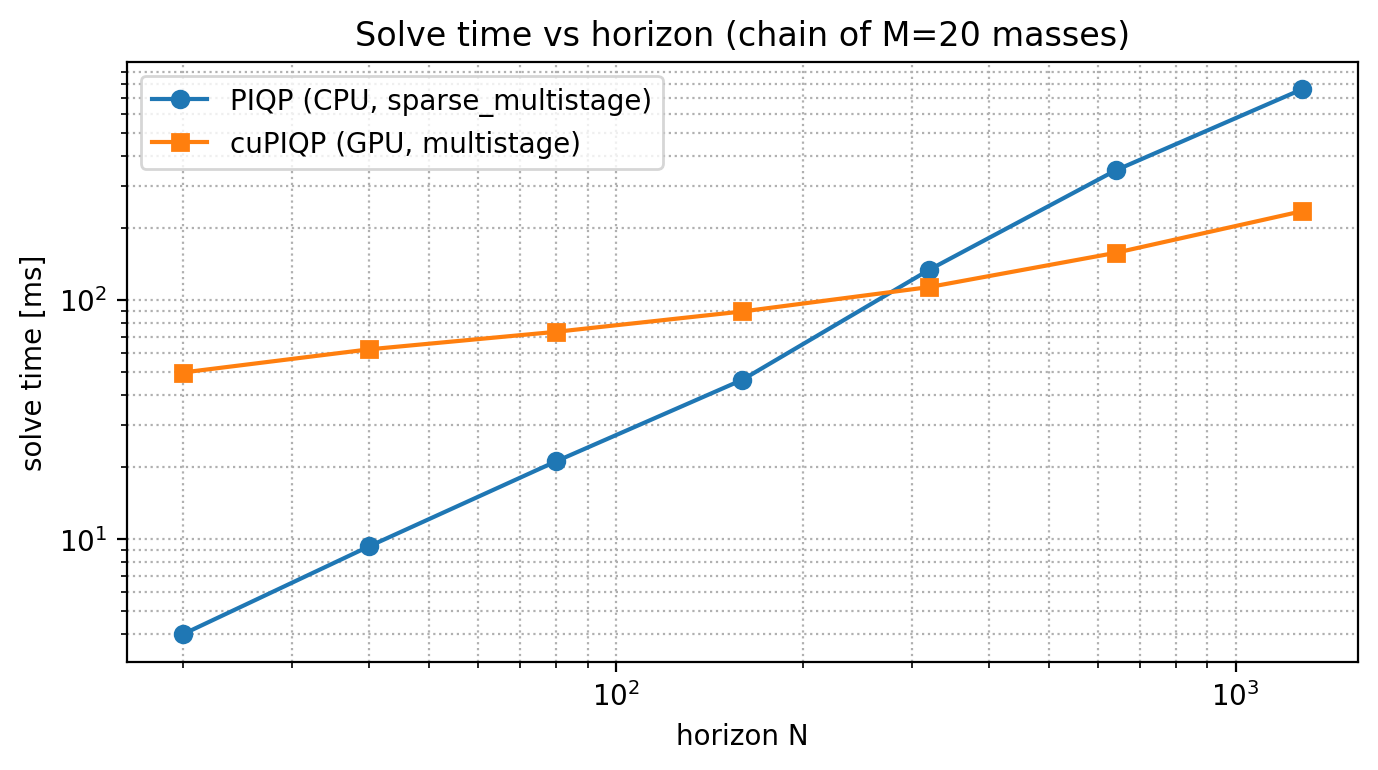

In [8]:
if _have_piqp:
	fig, ax = plt.subplots(figsize=(7, 4))
	ax.plot(horizons, t_cpu, "o-", label="PIQP (CPU, sparse_multistage)")
	ax.plot(horizons, t_gpu, "s-", label="cuPIQP (GPU, multistage)")
	ax.set_xscale("log")
	ax.set_yscale("log")
	ax.set_xlabel("horizon N")
	ax.set_ylabel("solve time [ms]")
	ax.set_title(f"Solve time vs horizon (chain of M={M} masses)")
	ax.grid(True, which="both", ls=":")
	ax.legend()
	fig.tight_layout()
	plt.show()


### What the scaling shows

The two curves come straight from *how* each solver factorizes the block-tridiagonal KKT system:

- PIQP's `sparse_multistage` KKT solver runs the classic sequential block-wise Cholesky factorization with $O(N)$ time complexity, i.e., **linear** in the horizon, reflected in the slope-1 line on the log-log axes: doubling $N$ doubles the solve time.
- CuPIQP  uses a parallel-in-horizon factorization with $O(\log N)$ time complexity, which explains why the curve is nearly flat (**logarithmic** in $N$).
